# Image generation for title covers

This notebook is used to generate blog post cover images for the Data Points site.


In [3]:
## import libraries
from PIL import Image, ImageDraw
import numpy as np
import torch

In [ ]:
## initialize the image colors -------------------------------------------
# Color names and hex codes are from https://zhongguose.com/
background_colors = {
    # #red-pink
    # "danfei" : "#f2cac9",
    # "jiahong" : "#eeaa9c",
    # "runhong" : "#f7cdbc",
    # "yufenhong" : "#e8b49a",
    # "chutaofenhong" : "#e8b49a",
    # "ouhe" : "#e8b49a",
    # "qianhui" : "#bbb5ac",

    #beige
    "mise" : "#e8b49a",
    "luoyingdanfen" : "#f9e8d0",
    "beige":"#E1CCBB"

    # #yellow-green
    # "miehuang" : "#f7de98",
    # "xingrenhuang" : "#f7e8aa",
    # "yuzan30" : "#a4cab6",
    # # "jialingshui" : "#add5a2",
    # "ganlanshi" : "#add5a2",

    # #blue
    # # "xinglan" : "#93b5cf",
    # # "hushuilan":"#b0d5df",

    # #gray
    # "yueyingbai" : "#c0c4c3",
    # "manaohui" : "#cfccc9",
    # "qianhui" : "#dad4cb",
    # "bangroubai" : "#f9f1db"
}

green_colors = {
    "yalv" : "#96c24e",
    "ganlanhuanglv":"#bec936",
    "yingwu": "#5bae23",
    "koushao":"#5dbe8a",
    "tonglv":"#2bae85",
    "zhulv":"#1ba784",
    "jiaochalv":"#553b18",
    "meidielv":"#12aa9c"
}

red_brown_colors = {
    "fupenzi":"#ac1f18",
    "exueshi":"#ab372f",
    "wuhuaguo":"#ab372f",
    "shehong":"#f19790",
    "xiangshuzong":"#773d31",
    "danlizong":"#673424",
    "zhumuhui":"#64483d",
    "chahe":"#5d3d21"
}

yellow_colors = {
    "jieguang":"#d9a40e",
    "youhuang":"#fcb70a",
    "zhizihuang":"#ebb10d",
    "xinhelv":"#d2b116"
}

blue_purple_colors = {
    "qingtinglan":"#3b818c",
    "mingfanlan":"#0f95b0",
    "canglan":"#134857",
    "pubulan":"#51c4d3",
    "gulan":"#1a94bc",
    "baoshilan":"#2486b9",
    "tianlan":"#1677b3",
    "feiyancao":"#0f59a4",
    "shangengzi":"#61649f",
    "yeju":"#525288",
    "tengluo":"#8076a3"
}

gray_colors = {
    "xiayun":"#617172",
    "xinhui":"#7a7374",
    "langyanhui":"#5d655f",
    "yuweihui":"#5e616d",
    "yanhui":"#80766e",
    "xiakeqing":"#869d9d",
    "qionghui":"#c4d7d6"
}

main_colors = {"green_colors":green_colors, 
    "red_brown_colors":red_brown_colors, 
    "yellow_colors":yellow_colors,
    "blue_purple_colors":blue_purple_colors,
    "gray_colors":gray_colors}


## helpers -------------------------------------------
def alpha_hex(opacity: float) -> str:
    """
    opacity: 0~1 (e.g. 0.3 for 30%)
    returns: '4D'
    """
    opacity = max(0, min(1, opacity))          # clamp safety
    return f"{round(opacity * 255):02X}"

def with_alpha(hex_color: str, opacity: float) -> str:
    hex_color = hex_color.lstrip("#")
    return f"#{hex_color}{alpha_hex(opacity)}"

In [12]:
## probabilistic line art in the style of the blog post -----------------------
import random
from IPython.display import display

CANVAS_WIDTH = 2000
CANVAS_HEIGHT = 900


def _normal(mu, sigma, size=None):
    """Helper around torch.distributions.Normal for scalar or batched samples."""
    dist = torch.distributions.Normal(mu, sigma)
    if size is None:
        return float(dist.sample(()))
    return dist.sample(size)


def draw_line_cluster(
    draw,
    center_x,
    num_lines,
    spread_x,
    top_mean,
    top_std,
    bottom_mean,
    bottom_std,
    min_length=80,
    base_width=1,
):
    """Draw one cluster of thin vertical lines and return (x, y0, y1) segments."""
    xs = _normal(center_x, spread_x, (num_lines,))
    y_tops = _normal(top_mean, top_std, (num_lines,))
    y_bottoms = _normal(bottom_mean, bottom_std, (num_lines,))

    segments = []
    for x, y0, y1 in zip(xs, y_tops, y_bottoms):
        x = float(x)
        y0 = float(y0)
        y1 = float(y1)

        if y0 > y1:
            y0, y1 = y1, y0

        # clamp to canvas
        y0 = max(0, min(CANVAS_HEIGHT, y0))
        y1 = max(0, min(CANVAS_HEIGHT, y1))
        if y1 - y0 < min_length:
            continue

        # base light line
        draw.line([(x, y0), (x, y1)], fill="#e0e0e0", width=base_width)
        segments.append((x, y0, y1))

    return segments


def decorate_segments_with_shapes(draw, segments):
    """Attach exactly one shape to each line.

    - Rectangles: one vertical side shares the same x as the line.
    - Circles: tangent to the line (circle just touches the line).
    """
    for x, y0, y1 in segments:
        if y1 <= y0:
            continue

        line_height = y1 - y0

        # choose a vertical position along the line for the attachment
        margin = 0.1 * line_height
        if line_height <= 2 * margin:
            attach_y = (y0 + y1) / 2
        else:
            attach_y = random.uniform(y0 + margin, y1 - margin)

        # decide shape type for this line
        choice = random.random()

        if choice < 0.5:
            # rectangle: one side aligned with the line's x
            rect_height = random.uniform(0.05 * line_height, 0.25 * line_height)
            rect_width = random.uniform(rect_height * 0.3, rect_height * 2.0)

            side = random.choice(["left", "right"])
            if side == "left":
                x0_rect = x - rect_width
                x1_rect = x
            else:
                x0_rect = x
                x1_rect = x + rect_width

            y0_rect = attach_y - rect_height / 2
            y1_rect = attach_y + rect_height / 2

            draw.rectangle([(x0_rect, y0_rect), (x1_rect, y1_rect)], fill="black")

        else:
            # circle tangent to the line
            max_radius = 0.15 * line_height
            min_radius = 3
            radius = random.uniform(min_radius, max(max_radius, min_radius + 1))

            side = random.choice(["left", "right"])
            cx = x - radius if side == "left" else x + radius
            cy = attach_y

            bbox = [cx - radius, cy - radius, cx + radius, cy + radius]
            if random.random() < 0.6:
                draw.ellipse(bbox, fill="black")
            else:
                draw.ellipse(bbox, outline="black", width=2)


def generate_final_image(seed=None, save_path=None, show=True):
    """Generate a full image resembling the reference final product."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

    img = Image.new("RGB", (CANVAS_WIDTH, CANVAS_HEIGHT), "white")
    draw = ImageDraw.Draw(img)

    # three clusters of vertical lines, placed closer together horizontally
    clusters = [
        # big cluster on the left
        dict(
            center_x=CANVAS_WIDTH * 0.26,
            num_lines=70,
            spread_x=CANVAS_WIDTH * 0.03,
            top_mean=CANVAS_HEIGHT * 0.05,
            top_std=CANVAS_HEIGHT * 0.08,
            bottom_mean=CANVAS_HEIGHT * 0.9,
            bottom_std=CANVAS_HEIGHT * 0.08,
        ),
        # middle cluster
        dict(
            center_x=CANVAS_WIDTH * 0.42,
            num_lines=24,
            spread_x=CANVAS_WIDTH * 0.025,
            top_mean=CANVAS_HEIGHT * 0.18,
            top_std=CANVAS_HEIGHT * 0.12,
            bottom_mean=CANVAS_HEIGHT * 0.95,
            bottom_std=CANVAS_HEIGHT * 0.06,
        ),
        # compact cluster on the right
        dict(
            center_x=CANVAS_WIDTH * 0.58,
            num_lines=45,
            spread_x=CANVAS_WIDTH * 0.022,
            top_mean=CANVAS_HEIGHT * 0.15,
            top_std=CANVAS_HEIGHT * 0.08,
            bottom_mean=CANVAS_HEIGHT * 0.9,
            bottom_std=CANVAS_HEIGHT * 0.05,
        ),
    ]

    for params in clusters:
        segs = draw_line_cluster(draw, **params)
        decorate_segments_with_shapes(draw, segs)

    if save_path is not None:
        img.save(save_path, dpi=(300, 300))

    if show:
        display(img)

    return img


# Example usage inside the notebook:


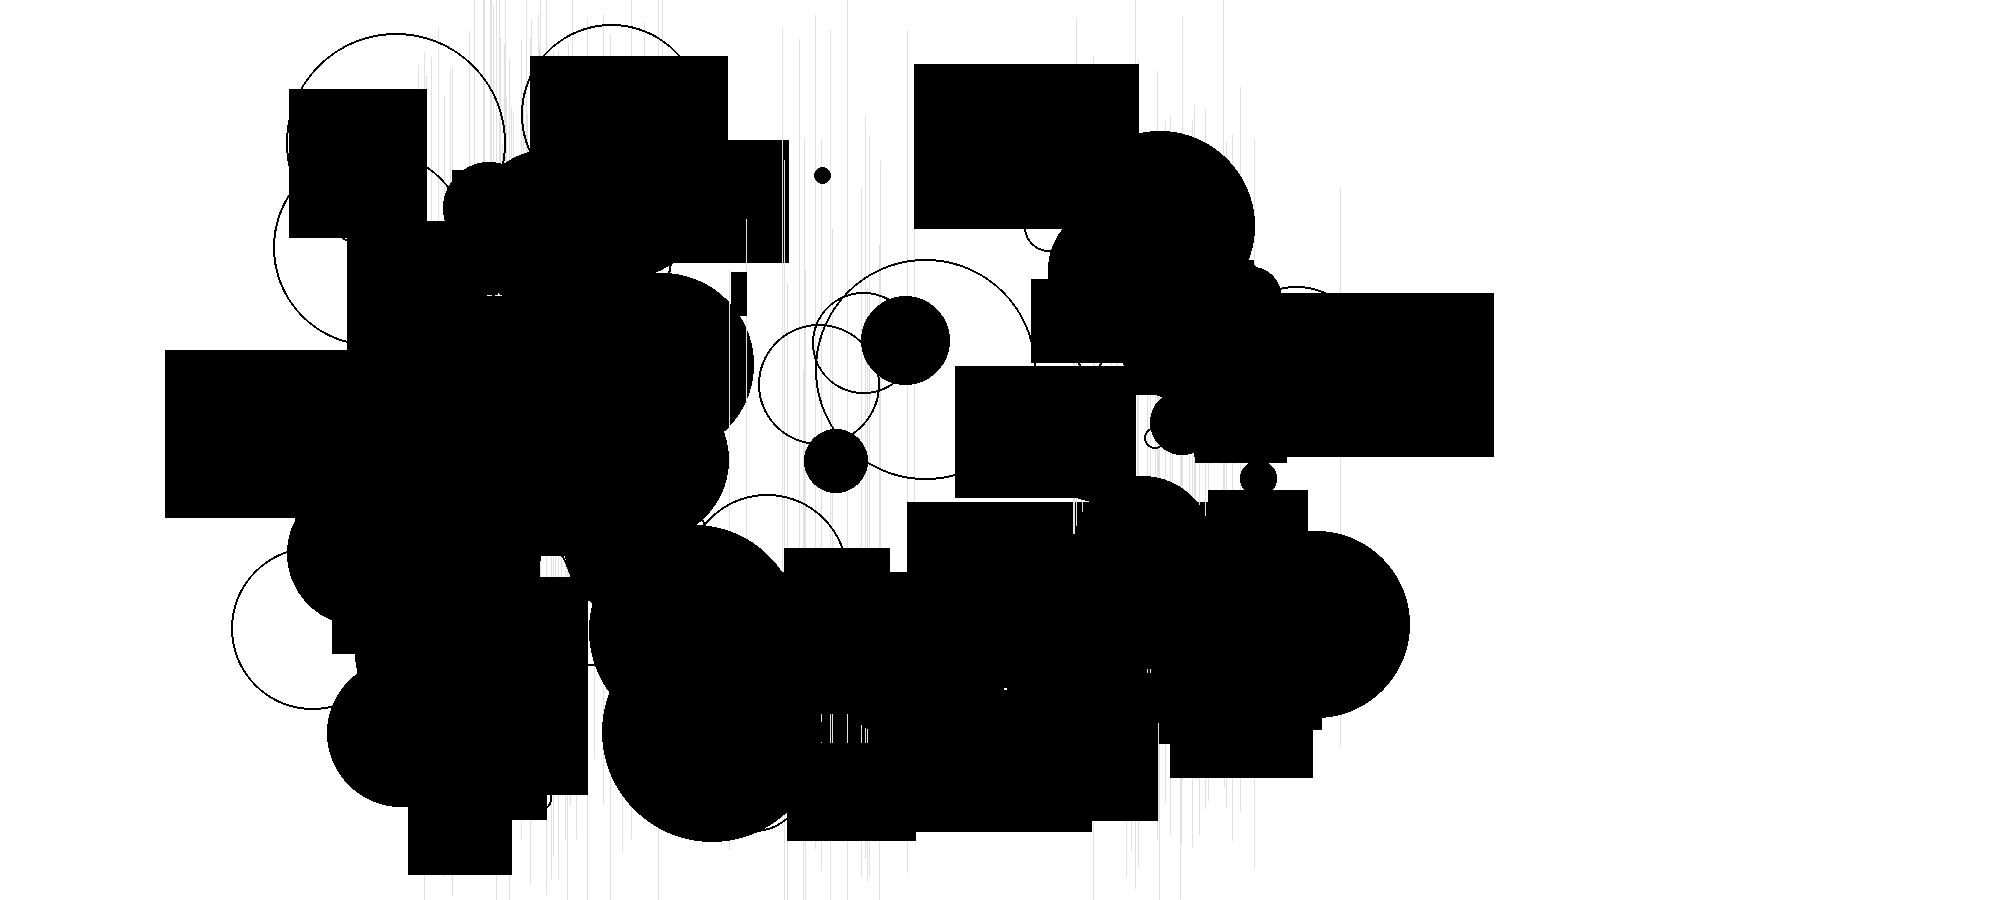

In [13]:
 _ = generate_final_image(seed=00, save_path="probabilistic_lines.png")


In [11]:
# --- Code replicated from the blog examples (rectangles, lines, circles) ---

import torch
from PIL import Image, ImageDraw
import numpy as np

# ---------------- Step 1: sampling rectangles ----------------
canvas_height = 1000
canvas_width = 1500

# loop to show different values
for i in range(5):
    # create normal distribution to sample from
    start_y_dist = torch.distributions.Normal(canvas_height * 0.8, canvas_height * 0.05)
    # sample from distribution
    start_y = int(start_y_dist.sample())

    # create normal distribution to sample height from
    height_dist = torch.distributions.Normal(canvas_height * 0.2, canvas_height * 0.05)

    height = int(height_dist.sample())
    end_y = start_y + height

    # start_x is fixed because of this being centered
    start_x = canvas_width // 2
    width_dist = torch.distributions.Normal(height * 0.5, height * 0.1)

    width = int(width_dist.sample())
    end_x = start_x + width

    print(f"start_x: {start_x}, end_x: {end_x}, start_y: {start_y}, end_y: {end_y}, width: {width}, height: {height}")

# Create a new image with white background and draw rectangles
for i in range(5):
    img = Image.new('RGB', (canvas_width, canvas_height), 'white')

    draw = ImageDraw.Draw(img)

    # Creating normal distributions to sample from
    start_y_dist = torch.distributions.Normal(canvas_height * 0.8, canvas_height * 0.05)
    start_y = int(start_y_dist.sample())

    height_dist = torch.distributions.Normal(canvas_height * 0.2, canvas_height * 0.05)
    height = int(height_dist.sample())
    end_y = start_y + height

    start_x = canvas_width // 2
    width_dist = torch.distributions.Normal(height * 0.5, height * 0.1)
    width = int(width_dist.sample())
    end_x = start_x + width

    # Drawing the rectangle
    draw.rectangle([(start_x, start_y), (end_x, end_y)], outline='black')

    img.show()


# ---------------- Step 2: sampling vertical lines ----------------

# Setting the size of the canvas
canvas_size = 1000
# Number of lines
num_lines = 10
# Create distributions for start and end y-coordinates and x-coordinate
y_start_distribution = torch.distributions.Normal(canvas_size / 2, canvas_size / 4)
y_end_distribution = torch.distributions.Normal(canvas_size / 2, canvas_size / 4)
x_distribution = torch.distributions.Normal(canvas_size / 2, canvas_size / 4)
# Sample from the distributions for each line
y_start_points = y_start_distribution.sample((num_lines,))
y_end_points = y_end_distribution.sample((num_lines,))
x_points = x_distribution.sample((num_lines,))
# Create a white canvas
image = Image.new('RGB', (canvas_size, canvas_size), 'white')
draw = ImageDraw.Draw(image)
# Draw the lines
for i in range(num_lines):
    draw.line([(x_points[i], y_start_points[i]), (x_points[i], y_end_points[i])], fill='black')
# Display the image
image.show()


# ---------------- Step 3: sampling circles with a half-normal distribution ----------------

# Define your line length
L = 3000

# Calculate the desired mean for the half-normal distribution
mu = np.sqrt(L * 2)

# Calculate the scale parameter that gives the desired mean
scale = mu / np.sqrt(2 / np.pi)

# Create a half-normal distribution with the calculated scale parameter
dist = torch.distributions.HalfNormal(scale / 3)

# Sample and draw multiple circles
for _ in range(10):
    # Create a new image with white background
    img_size = (2000, 2000)
    img = Image.new('RGB', img_size, (255, 255, 255))
    draw = ImageDraw.Draw(img)

    # Define the center of the circles
    start_x = img_size[0] // 2
    start_y = img_size[1] // 2
    # Sample a radius from the distribution
    r = int(dist.sample())

    print(f"Sampled radius: {r}")

    # Define the bounding box for the circle
    bbox = [start_x - r, start_y - r, start_x + r, start_y + r]

    # Draw the circle onto the image
    draw.ellipse(bbox, outline='black', fill=(0, 0, 0))

    # Display the image
    img.show()


start_x: 750, end_x: 848, start_y: 794, end_y: 987, width: 98, height: 193
start_x: 750, end_x: 872, start_y: 759, end_y: 1002, width: 122, height: 243
start_x: 750, end_x: 854, start_y: 775, end_y: 1010, width: 104, height: 235
start_x: 750, end_x: 847, start_y: 902, end_y: 1100, width: 97, height: 198
start_x: 750, end_x: 863, start_y: 860, end_y: 1052, width: 113, height: 192
Sampled radius: 29
Sampled radius: 48
Sampled radius: 4
Sampled radius: 49
Sampled radius: 13
Sampled radius: 37
Sampled radius: 6
Sampled radius: 24
Sampled radius: 41
Sampled radius: 9


In [22]:
# --- Combined version using the blog-style distributions,
# --- with one attached shape (rect or circle) per line.

import torch
from PIL import Image, ImageDraw
import numpy as np
import random


def generate_blog_style_attached(canvas_width=3000, canvas_height=2000, num_lines=40):
    # Distributions similar to the blog's line example
    x_dist = torch.distributions.Normal(canvas_width / 2, canvas_width / 4)
    y_start_dist = torch.distributions.Normal(canvas_height / 2, canvas_height / 4)
    y_end_dist = torch.distributions.Normal(canvas_height / 2, canvas_height / 4)

    x_points = x_dist.sample((num_lines,))
    y_start_points = y_start_dist.sample((num_lines,))
    y_end_points = y_end_dist.sample((num_lines,))

    img = Image.new("RGB", (canvas_width, canvas_height), "white")
    draw = ImageDraw.Draw(img)

    # Half-normal distribution for circle radius (from the blog code), but we will clamp it
    L = 3000
    mu = np.sqrt(L * 2)
    scale = mu / np.sqrt(2 / np.pi)
    radius_dist = torch.distributions.HalfNormal(scale / 3)

    for i in range(num_lines):
        x = float(x_points[i])
        y0 = float(y_start_points[i])
        y1 = float(y_end_points[i])

        # sort and clamp to canvas
        if y0 > y1:
            y0, y1 = y1, y0
        y0 = max(0, min(canvas_height, y0))
        y1 = max(0, min(canvas_height, y1))
        if y1 - y0 < 10:
            continue

        # draw the vertical line
        draw.line([(x, y0), (x, y1)], fill="black", width=2)

        line_height = y1 - y0
        margin = 0.1 * line_height
        attach_y = (y0 + y1) / 2 if line_height <= 2 * margin else random.uniform(y0 + margin, y1 - margin)

        # choose shape type: rectangle or circle
        if random.random() < 0.5:
            # Rectangle: sizes inspired by Step 1 code, with reduced max size
            raw_height = float(torch.distributions.Normal(canvas_height * 0.2, canvas_height * 0.05).sample())
            raw_width = float(torch.distributions.Normal(abs(raw_height) * 0.5, abs(raw_height) * 0.1).sample())

            # keep same minimum, halve the previous max
            rect_height = max(8, min(abs(raw_height), line_height * 0.35))
            rect_width = max(8, min(abs(raw_width), rect_height * 2.0))

            side = random.choice(["left", "right"])
            if side == "left":
                x0_rect = x - rect_width
                x1_rect = x
            else:
                x0_rect = x
                x1_rect = x + rect_width

            y0_rect = attach_y - rect_height / 2
            y1_rect = attach_y + rect_height / 2

            # random fill: some filled, some only border, but always keep outline
            if random.random() < 0.5:
                fill_color = "black"
            else:
                fill_color = None
            draw.rectangle([(x0_rect, y0_rect), (x1_rect, y1_rect)], outline="black", fill=fill_color)
        else:
            # Circle: radius from half-normal, then clamped; tangent to the line
            r = float(radius_dist.sample())
            max_r = min(line_height * 0.15, canvas_height * 0.125)  # halve previous max
            r = max(4.0, min(r, max_r))

            side = random.choice(["left", "right"])
            cx = x - r if side == "left" else x + r
            cy = attach_y

            bbox = [cx - r, cy - r, cx + r, cy + r]
            # random fill: sometimes filled, sometimes hollow, always with border
            if random.random() < 0.5:
                fill_color = "black"
            else:
                fill_color = None
            draw.ellipse(bbox, outline="black", fill=fill_color)

    return img


# Example usage:
# img = generate_blog_style_attached()
# img.show()


In [25]:
img = generate_blog_style_attached()
img.show()
# To save a high-resolution file for the blog, you can also do:
# img.save("probabilistic_lines_hi_res.png", dpi=(300, 300))